In [ ]:
# Data Analysis and Preprocessing
import numpy as np
import pandas as pd

# Data Set Visualization
import matplotlib.pyplot as plt

# Training and Testing the Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Model Saving
import pickle

In [35]:
# Load data from CSV file
data = pd.read_csv("./Data/InsuranceData.csv")
print(data.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [ ]:
# Basic EDA (Exploratory Data Analysis)
print(data.describe()) # To get the statistical summary of the data
print()
print(data.info()) # To get the information about the data types and null values

               age          sex          bmi     children       smoker  \
count  1338.000000  1338.000000  1338.000000  1338.000000  1338.000000   
mean     39.207025     0.494768    30.663397     1.094918     0.204783   
std      14.049960     0.500160     6.098187     1.205493     0.403694   
min      18.000000     0.000000    15.960000     0.000000     0.000000   
25%      27.000000     0.000000    26.296250     0.000000     0.000000   
50%      39.000000     0.000000    30.400000     1.000000     0.000000   
75%      51.000000     1.000000    34.693750     2.000000     0.000000   
max      64.000000     1.000000    53.130000     5.000000     1.000000   

            charges  region_northwest  region_southeast  region_southwest  \
count   1338.000000       1338.000000       1338.000000       1338.000000   
mean   13270.422265          0.242900          0.272048          0.242900   
std    12110.011237          0.428995          0.445181          0.428995   
min     1121.873900      

In [36]:
# Encoding categorical variables

# Encoding 'sex' and 'smoker' columns using label encoding
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data['smoker'] = data['smoker'].map({'no': 0, 'yes': 1})

# Encoding 'region' column using one-hot encoding
data = pd.get_dummies(data, columns=['region'], drop_first=True)

data['region_northwest'] = data['region_northwest'].astype(int)
data['region_southeast'] = data['region_southeast'].astype(int)
data['region_southwest'] = data['region_southwest'].astype(int)

In [37]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0


In [38]:
# To see the correlation between the features and the target variable
# if correlation is high then we can drop the feature as it will not add much value to the model
data.corr(numeric_only=True)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
age,1.000000,0.020856,0.109272,0.042469,-0.025019,0.299008,-0.000407,-0.011642,0.010016
sex,0.020856,1.000000,-0.046371,-0.017163,-0.076185,-0.057292,0.011156,-0.017117,0.004184
bmi,0.109272,-0.046371,1.000000,0.012759,0.003750,0.198341,-0.135996,0.270025,-0.006205
children,0.042469,-0.017163,0.012759,1.000000,0.007673,0.067998,0.024806,-0.023066,0.021914
smoker,-0.025019,-0.076185,0.003750,0.007673,1.000000,0.787251,-0.036945,0.068498,-0.036945
charges,0.299008,-0.057292,0.198341,0.067998,0.787251,1.000000,-0.039905,0.073982,-0.043210
region_northwest,-0.000407,0.011156,-0.135996,0.024806,-0.036945,-0.039905,1.000000,-0.346265,-0.320829
region_southeast,-0.011642,-0.017117,0.270025,-0.023066,0.068498,0.073982,-0.346265,1.000000,-0.346265
region_southwest,0.010016,0.004184,-0.006205,0.021914,-0.036945,-0.043210,-0.320829,-0.346265,1.000000


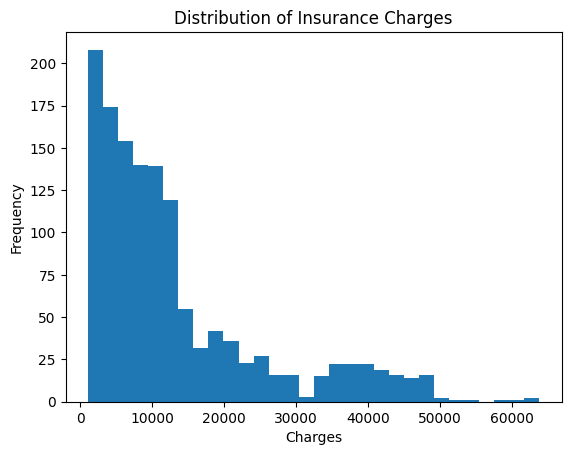

In [39]:
# histogram of the target variable, to check if it is normally distributed or not, if it is not normally distributed 
# then we can apply log transformation to make it normally distributed

plt.hist(data['charges'], bins=30)
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Insurance Charges")
plt.show()

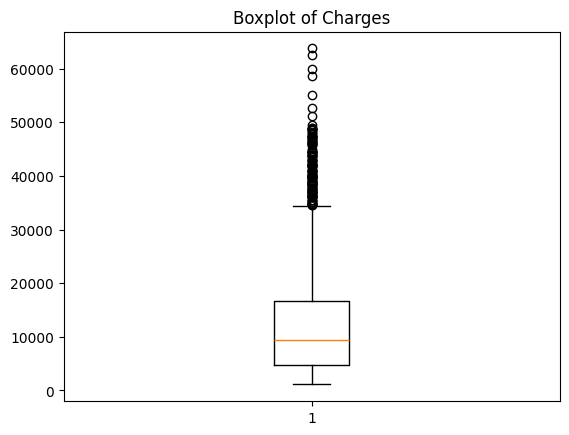

In [40]:
# Boxplot to check for outliers in the target variable

plt.boxplot(data['charges'])
plt.title("Boxplot of Charges")
plt.show()

In [43]:
# Charges are Rigth skewed, so we can apply log transformation to make it normally distributed
data['log_charges'] = np.log1p(data['charges'])

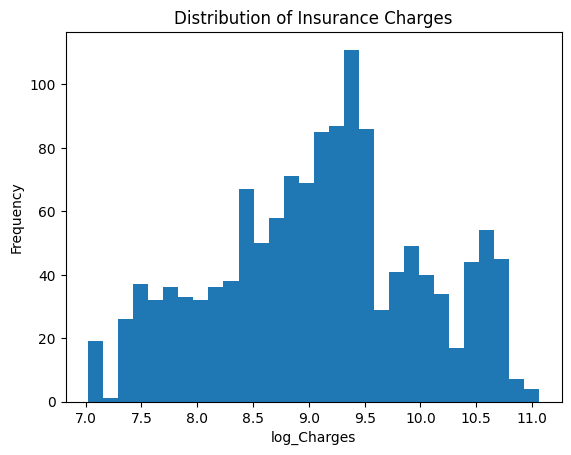

In [44]:
# histogram of the target variable, to check if it is normally distributed or not, if it is not normally distributed 
# then we can apply log transformation to make it normally distributed

plt.hist(data['log_charges'], bins=30)
plt.xlabel("log_Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Insurance Charges")
plt.show()

In [48]:
# Training the Linear Regression Model

# Setting X and y axis
X = data.drop(['charges', 'log_charges'], axis=1)
y = data['log_charges']

In [49]:
# Splting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
# Training the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
pred = model.predict(X_test)
print("R2:", r2_score(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

R2: 0.8047410791393022
MSE: 0.17550910855320748


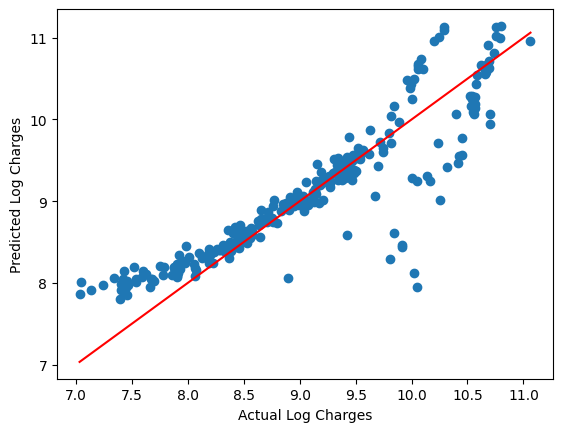

In [ ]:
# Plotting the actual vs predicted values
plt.scatter(y_test, pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Log Charges")
plt.ylabel("Predicted Log Charges")
plt.show()

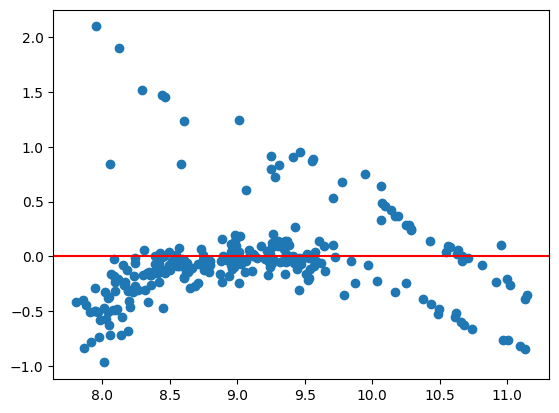

In [53]:
residuals = y_test - pred
plt.scatter(pred, residuals)
plt.axhline(0, color='red')
plt.show()


In [60]:
# Test the model with real data
sample = X.iloc[0:1].copy()
sample[:] = 0

sample['age'] = 30
sample['sex'] = 0     
sample['bmi'] = 25
sample['children'] = 1
sample['smoker'] = 0  
sample['region_southeast'] = 1

log_pred = model.predict(sample)
real_charge = np.expm1(log_pred)

print("Predicted Insurance Cost:", real_charge[0])

Predicted Insurance Cost: 4006.7500934919494


In [ ]:
# Saving the Model
pickle.dump(model, open("insurance_model.pkl", "wb"))

pickle.dump(list(X.columns), open("model_columns.pkl", "wb"))